<a href="https://colab.research.google.com/github/sanikahanure/MLProject/blob/main/ML_on_Student_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# uploading file
from google.colab import files
upload=files.upload()

Saving ai_impact_student_performance_dataset.csv to ai_impact_student_performance_dataset.csv


In [57]:
# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
!pip install imblearn

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing   import StandardScaler, LabelEncoder

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import SVC

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)

# ── Class Imbalance ───────────────────────────────────────────────────────────
from sklearn.utils import resample

# ── Multiclass ROC helpers ────────────────────────────────────────────────────
from sklearn.preprocessing import label_binarize
from itertools import cycle

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

PALETTE = ['#4C72B0', '#55A868', '#C44E52']   # one colour per class
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

df=pd.read_csv('ai_impact_student_performance_dataset.csv')
print(df.head())

   student_id  age  gender grade_level  study_hours_per_day  uses_ai  \
0           1   20  Female    1st Year                  2.5        1   
1           2   17    Male        12th                  3.4        1   
2           3   24    Male    3rd Year                  0.8        0   
3           4   21  Female        12th                  4.4        0   
4           5   18   Other    3rd Year                  3.5        1   

   ai_usage_time_minutes   ai_tools_used ai_usage_purpose  \
0                    170             NaN        Exam Prep   
1                    123             NaN            Notes   
2                     35         Copilot    Doubt Solving   
3                     45  ChatGPT+Gemini            Notes   
4                     21  ChatGPT+Gemini           Coding   

   ai_dependency_score  ...  concept_understanding_score  \
0                   10  ...                            4   
1                    4  ...                            8   
2                   

In [4]:
df.describe()

,student_id,age,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,...,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed
count,8000.00000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,18.96725,3.286938,0.641000,88.989875,5.515125,50.057500,59.359500,5.472375,59.501250,...,69.852112,5.484750,5.516450,10.127325,6.465025,3.010600,2.523387,5.463375,56.811988,0.889250
std,2309.54541,3.15316,1.582171,0.479737,52.184077,2.883064,29.440109,34.869496,2.872067,23.161888,...,17.234339,2.898546,2.586377,17.479288,1.435670,1.744974,1.436991,2.881917,13.455724,0.313842
min,1.00000,14.00000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,20.000000,...,40.000000,1.000000,1.000000,-20.000000,4.000000,0.000000,0.000000,1.000000,12.700000,0.000000
25%,2000.75000,16.00000,1.900000,0.000000,43.000000,3.000000,25.000000,29.000000,3.000000,39.750000,...,54.800000,3.000000,3.200000,-5.000000,5.200000,1.500000,1.300000,3.000000,47.300000,1.000000
50%,4000.50000,19.00000,3.300000,1.000000,89.000000,6.000000,50.000000,59.000000,6.000000,59.000000,...,70.000000,5.000000,5.500000,10.150000,6.400000,3.000000,2.500000,5.000000,56.900000,1.000000
75%,6000.25000,22.00000,4.600000,1.000000,134.000000,8.000000,76.000000,90.000000,8.000000,80.000000,...,84.600000,8.000000,7.800000,25.500000,7.700000,4.500000,3.800000,8.000000,66.200000,1.000000
max,8000.00000,24.00000,6.000000,1.000000,179.000000,10.000000,100.000000,119.000000,10.000000,99.000000,...,100.000000,10.000000,10.000000,40.000000,9.000000,6.000000,5.000000,10.000000,95.800000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_ethics_score     

In [6]:
#missing values
print('Missing values in the dataset:')
display(df.isnull().sum())


Missing values in the dataset:


,0
student_id,0
age,0
gender,0
grade_level,0
study_hours_per_day,0
uses_ai,0
ai_usage_time_minutes,0
ai_tools_used,1362
ai_usage_purpose,1346
ai_dependency_score,0


### Distribution of Numerical Features

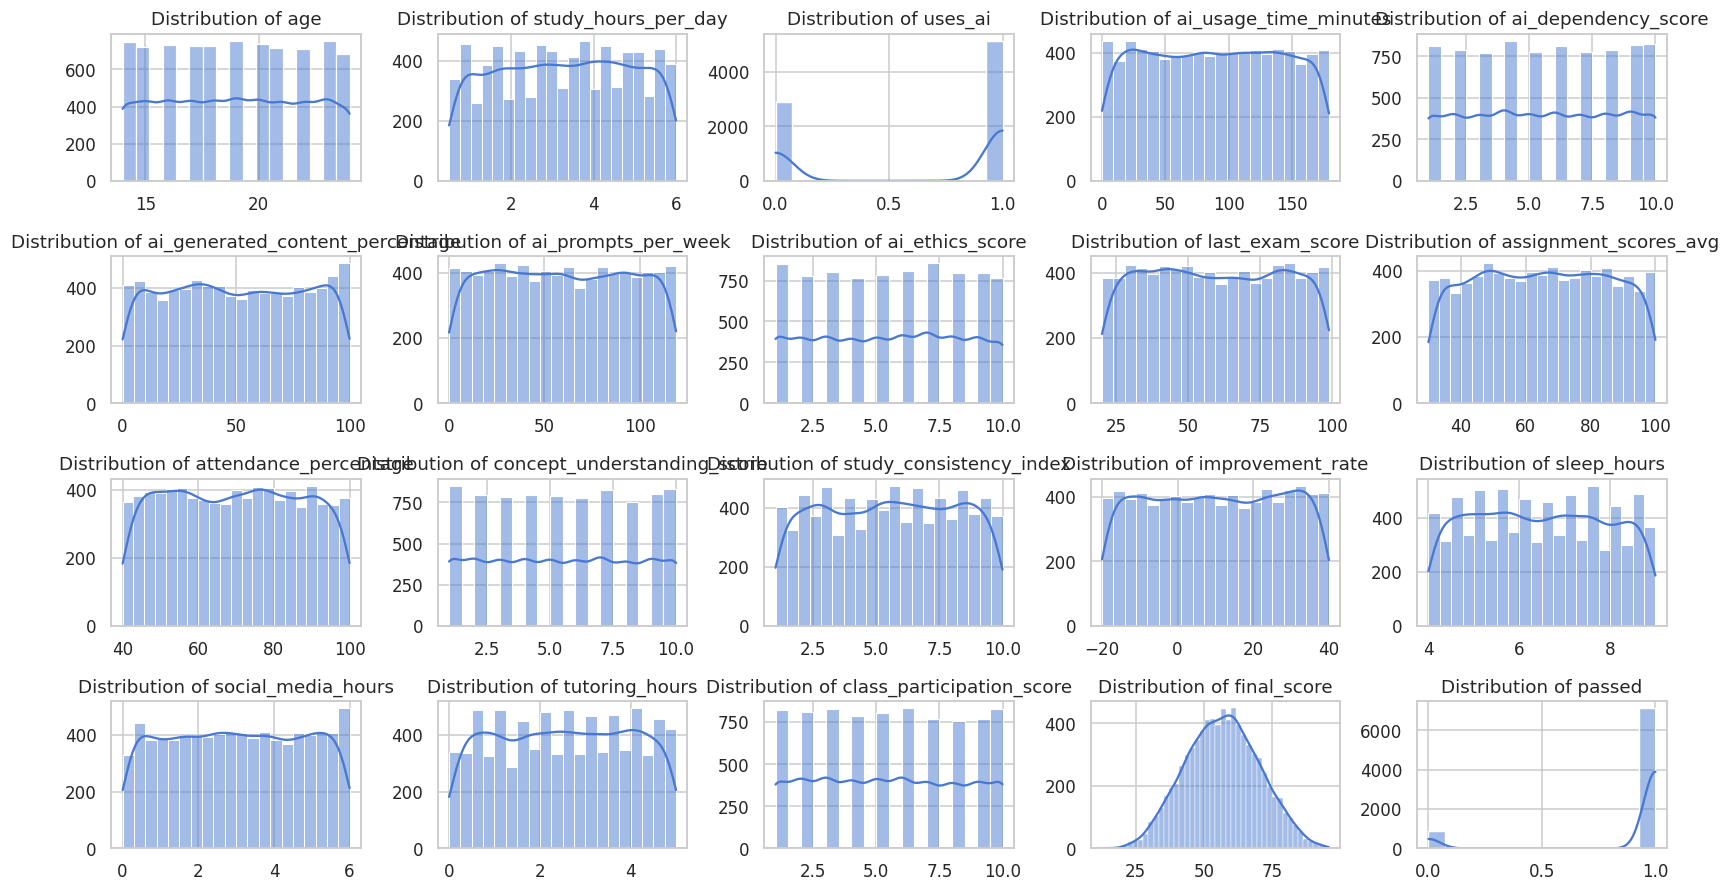

In [8]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Exclude 'student_id' as it's an identifier
numerical_cols = numerical_cols.drop('student_id', errors='ignore')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(5, 5, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

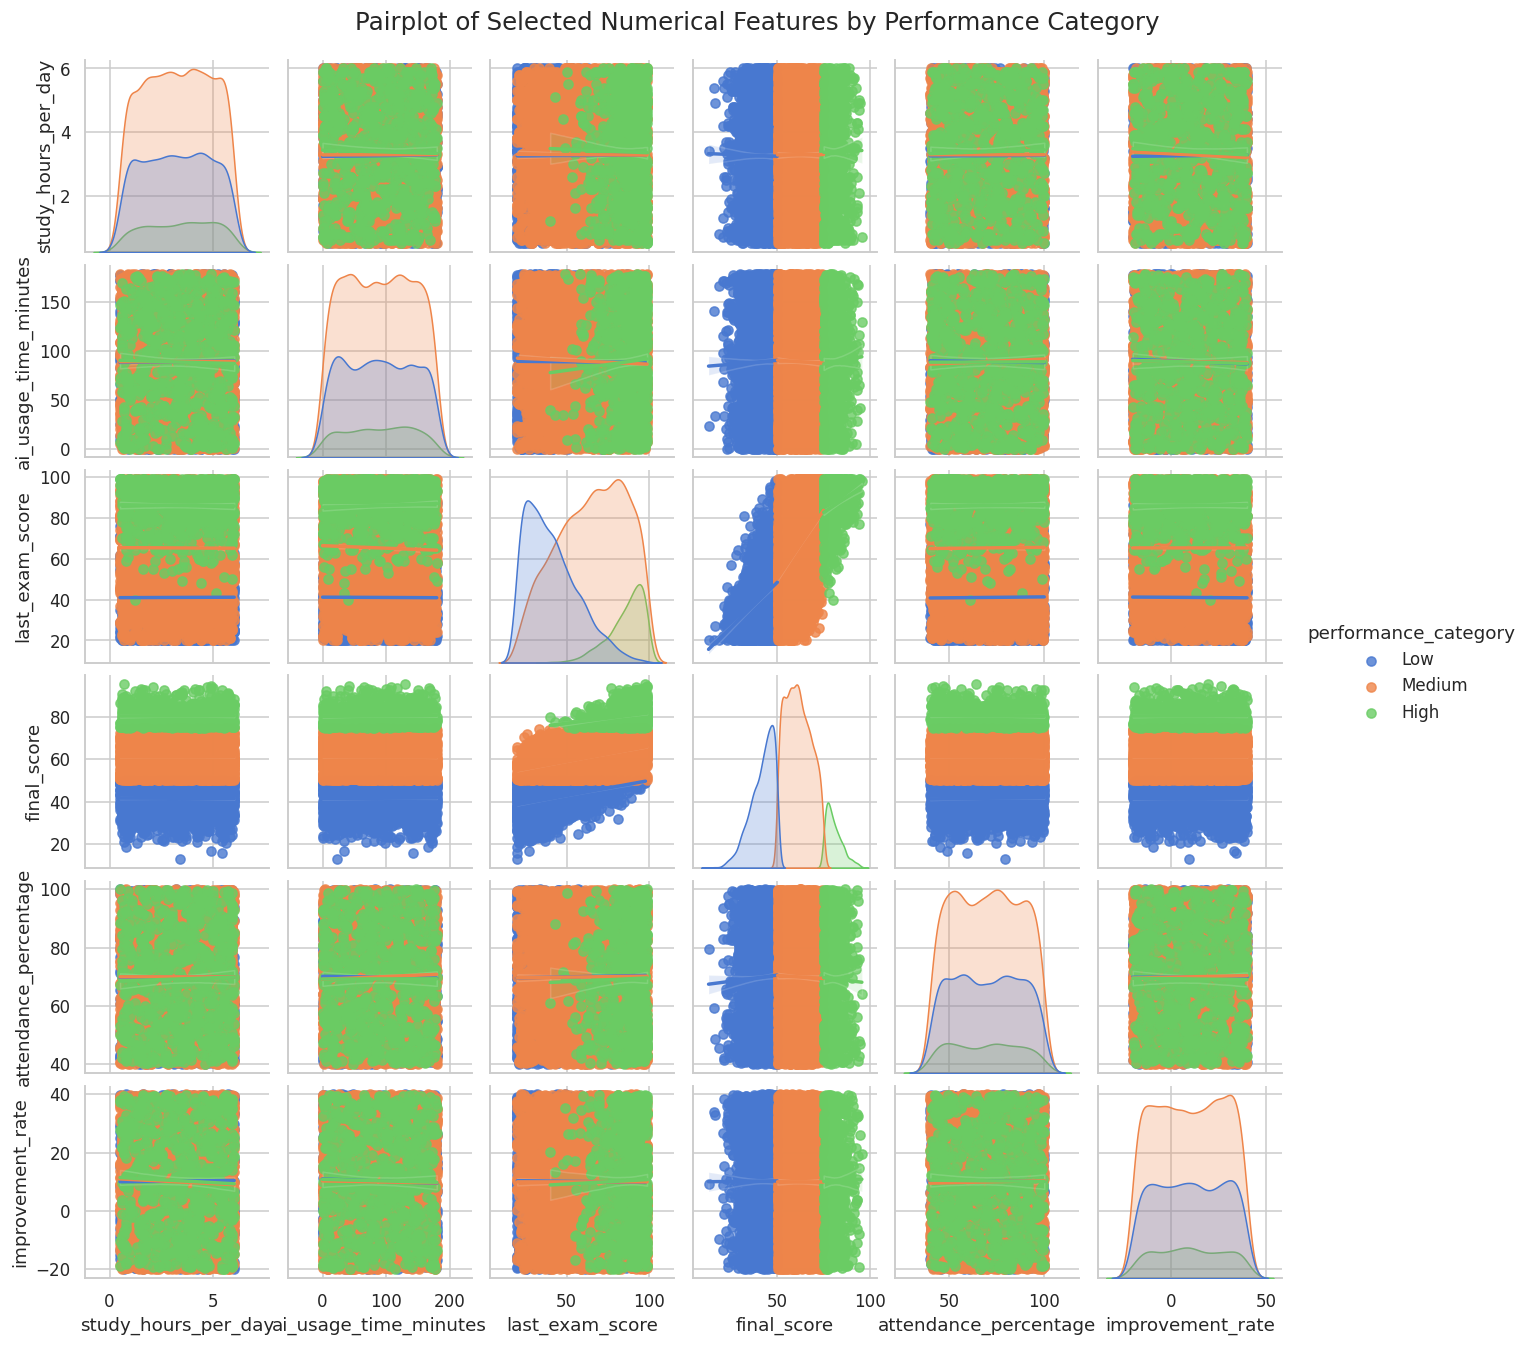

In [11]:
selected_features = [
    'study_hours_per_day',
    'ai_usage_time_minutes',
    'last_exam_score',
    'final_score',
    'attendance_percentage',
    'improvement_rate'
]

# Filter the DataFrame to include only the selected features and the hue column
df_subset = df[selected_features + ['performance_category']]

g_reduced = sns.pairplot(df_subset, hue='performance_category', diag_kind='kde', kind='reg', height=2)
plt.suptitle('Pairplot of Selected Numerical Features by Performance Category', y=1.02, fontsize=16)
plt.show()

In [22]:
#Encode target & scale features

from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to 'performance_category'
df['performance_category_encoded'] = le.fit_transform(df['performance_category'])

print('Performance Category Encoding:')
for name, code in zip(le.classes_, le.transform(le.classes_)):
    print(f'{name} -> {code}')

# Update the target variable 'y' to the encoded performance category
y = df['performance_category_encoded']

# Re-split the data with the new 'y'
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Performance Category Encoding:
High -> 0
Low -> 1
Medium -> 2


LOGISTIC **REGRESSION** *italicized text*

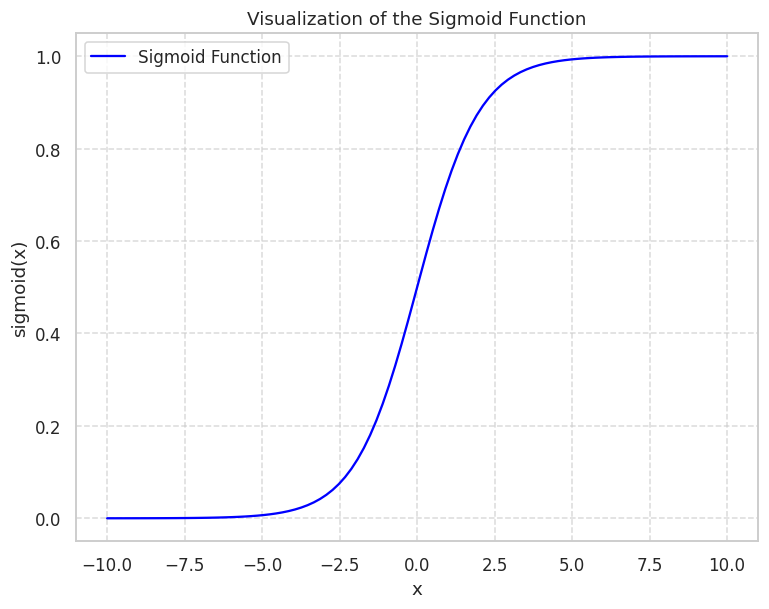

In [24]:
# Visualise the Sigmoid function

import numpy as np
import matplotlib.pyplot as plt

# Define the Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Generate a range of x values
x = np.linspace(-10, 10, 100)

# Calculate y values using the sigmoid function
y = sigmoid(x)

# Plot the Sigmoid function
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='Sigmoid Function', color='blue')
plt.title('Visualization of the Sigmoid Function')
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0       0.78      0.71      0.74       177
           1       0.96      0.97      0.97      1423

    accuracy                           0.94      1600
   macro avg       0.87      0.84      0.85      1600
weighted avg       0.94      0.94      0.94      1600



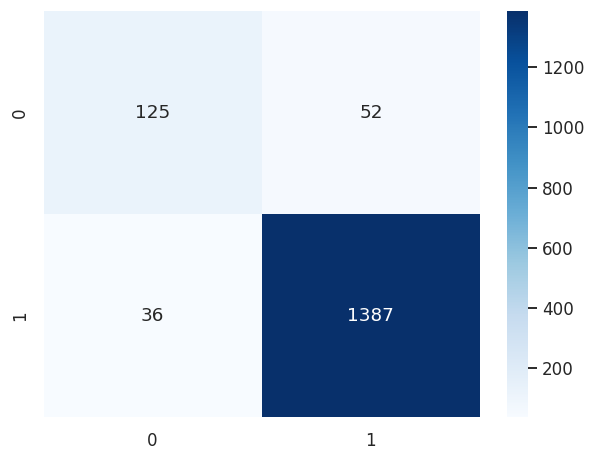

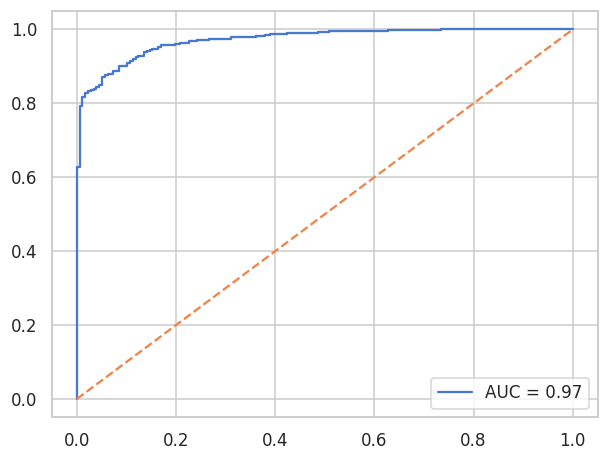

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Report
print(classification_report(y_test_binary, y_pred_binary))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test_binary, y_pred_binary),
            annot=True, fmt='d', cmap='Blues')
plt.show()

# ROC AUC
roc_auc = roc_auc_score(y_test_binary, y_pred_proba_binary)
fpr, tpr, _ = roc_curve(y_test_binary, y_pred_proba_binary)

# ROC Curve
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], '--')
plt.legend()
plt.show()

**SVM**

### Support Vector Machine (SVM) with Linear Kernel (User's Code)

In [34]:
svm_linear = SVC(
    kernel='linear',
    C=1.0,
    probability=True,     # enables predict_proba for ROC curves later
    random_state=42
)
svm_linear.fit(x_train_scaled_binary, y_train_binary)
y_pred_svm_lin = svm_linear.predict(x_test_scaled_binary)

print('SVM — Linear Kernel')
print(f'  Accuracy       : {accuracy_score(y_test_binary, y_pred_svm_lin):.4f}')
print(f'  Support Vectors: {svm_linear.n_support_}  (per class: [0, 1])') # Assuming classes are 0 and 1
print(f'  Total SVs      : {svm_linear.support_vectors_.shape[0]}')

SVM — Linear Kernel
  Accuracy       : 0.9456
  Support Vectors: [456 460]  (per class: [0, 1])
  Total SVs      : 916


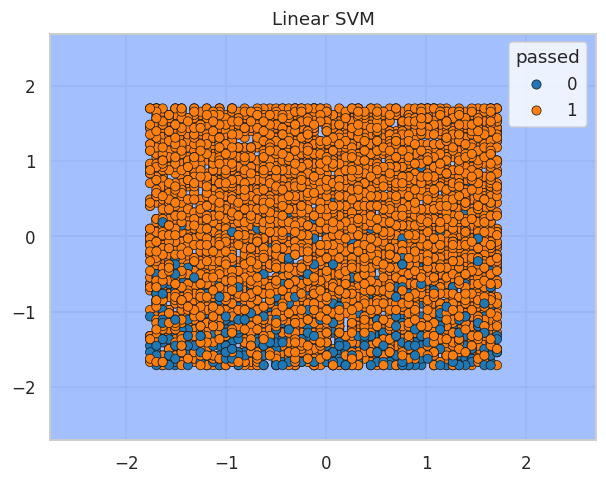

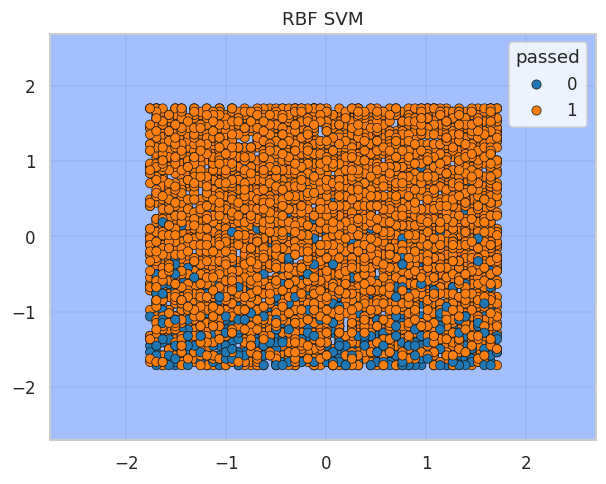

In [40]:
def plot_db(model, X, y, title):
    xx, yy = np.meshgrid(
        np.arange(X[:,0].min()-1, X[:,0].max()+1, 0.02),
        np.arange(X[:,1].min()-1, X[:,1].max()+1, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.8)
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette='tab10', edgecolor='k')
    plt.title(title)
    plt.show()

# Calls
plot_db(svm_linear_2d, x_train_scaled_2d, y_train_2d, "Linear SVM")
plot_db(svm_rbf_2d, x_train_scaled_2d, y_train_2d, "RBF SVM")

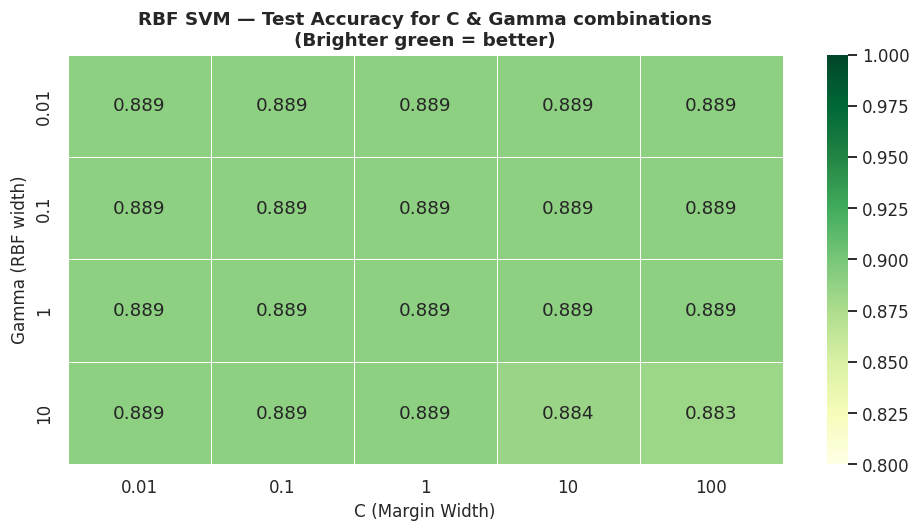

In [48]:
C_grid     = [0.01, 0.1, 1, 10, 100]
gamma_grid = [0.01, 0.1, 1, 10]

results_grid = np.zeros((len(gamma_grid), len(C_grid)))

for i, g in enumerate(gamma_grid):
    for j, c in enumerate(C_grid):
        m = SVC(kernel='rbf', C=c, gamma=g, random_state=42)
        m.fit(x_train_scaled_2d, y_train_2d)
        results_grid[i, j] = accuracy_score(y_test_2d, m.predict(x_test_scaled_2d))

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(results_grid, annot=True, fmt='.3f', cmap='YlGn',
            xticklabels=C_grid, yticklabels=gamma_grid, ax=ax,
            linewidths=0.5, linecolor='white', vmin=0.8, vmax=1.0)
ax.set_xlabel('C (Margin Width)', fontsize=11)
ax.set_ylabel('Gamma (RBF width)', fontsize=11)
ax.set_title('RBF SVM — Test Accuracy for C & Gamma combinations\n'
             '(Brighter green = better)', fontweight='bold')
plt.tight_layout()
plt.show()

PROBABILITY BASED CLASSIFICATION


In [43]:
#probability based classification
import pandas as pd

# Create a DataFrame to show actual, predicted, and probability values
results_df = pd.DataFrame({
    'Actual_Passed': y_test_binary,
    'Predicted_Passed': y_pred_binary,
    'Probability_Passed': y_pred_proba_binary
})

# Display the first few rows of the results, sorted by probability
display(results_df.head(10))

# Display some rows where the probability is close to the decision boundary (0.5)
print('\nRows where probability is close to 0.5:')
display(results_df[(results_df['Probability_Passed'] > 0.45) & (results_df['Probability_Passed'] < 0.5)].head(10))

,Actual_Passed,Predicted_Passed,Probability_Passed
6732,1,1,0.997813
1936,1,1,0.999901
1491,1,1,0.905081
1033,0,0,0.176911
5623,1,1,0.999947
2335,1,1,0.940181
4628,1,1,0.980536
6894,1,1,0.591092
5607,1,1,0.712870
534,1,1,0.999985



Rows where probability is close to 0.5:


,Actual_Passed,Predicted_Passed,Probability_Passed
4525,0,0,0.453358
1840,0,0,0.487749
2837,1,0,0.486494
6528,1,0,0.476059
2038,0,0,0.488853
7107,1,0,0.456902
6727,0,0,0.499447
6941,1,0,0.456380
6396,1,0,0.453370
6572,1,0,0.467012


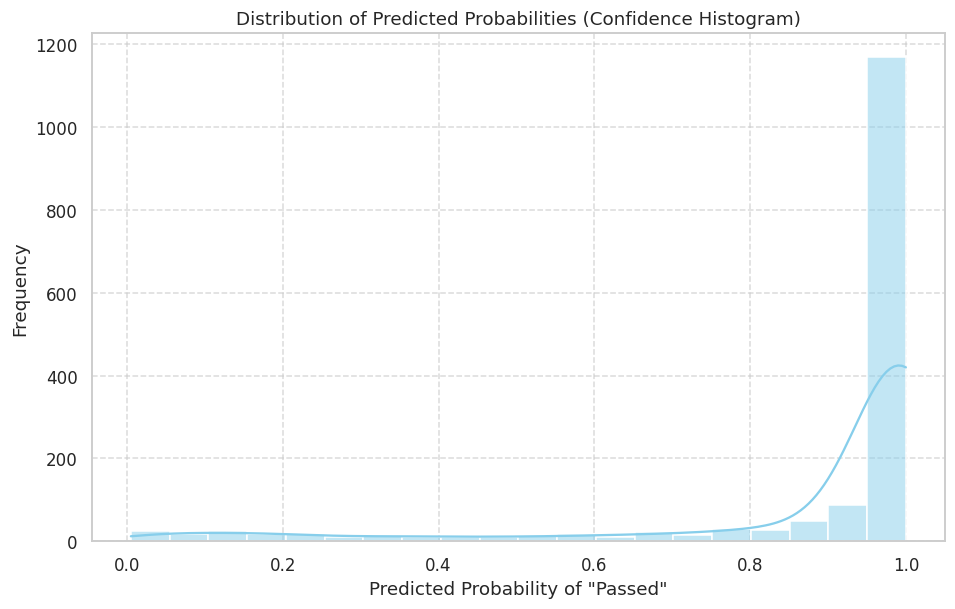

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_proba_binary, bins=20, kde=True, color='skyblue')
plt.title('Distribution of Predicted Probabilities (Confidence Histogram)')
plt.xlabel('Predicted Probability of "Passed"')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

HANDLING  CLASS  IMBALANCE

Imbalanced class distribution:
performance_category_encoded
0    753
1    500
2    300
Name: count, dtype: int64


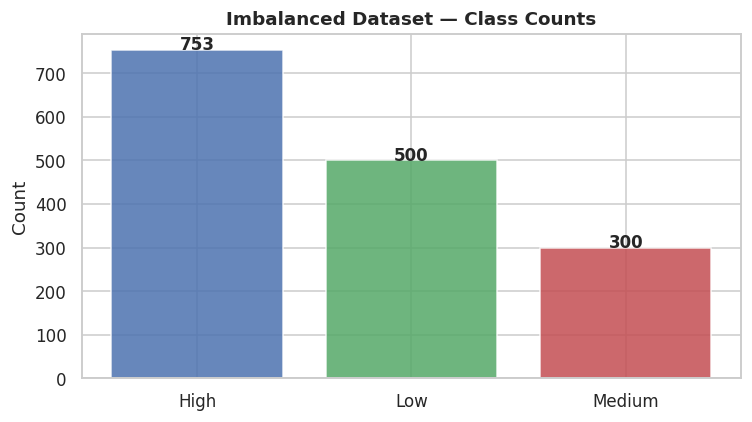

In [49]:
# ── 5A: Create an artificially imbalanced dataset ─────────────────────────────
# Keep all High, sample 500 Low, and 300 Medium performance students
df_high = df[df['performance_category_encoded'] == 0] # High
df_low = df[df['performance_category_encoded'] == 1].sample(500, random_state=42) # Low
df_medium = df[df['performance_category_encoded'] == 2].sample(300, random_state=42) # Medium

df_imb = pd.concat([df_high, df_low, df_medium]).reset_index(drop=True)

print('Imbalanced class distribution:')
print(df_imb['performance_category_encoded'].value_counts().sort_index())

X_imb = df_imb[X.columns] # Use X.columns as FEATURES
y_imb = df_imb['performance_category_encoded'] # Already encoded

X_imb_tr, X_imb_te, y_imb_tr, y_imb_te = train_test_split(
    X_imb, y_imb, test_size=0.25, random_state=42, stratify=y_imb
)

sc2 = StandardScaler()
X_imb_tr_sc = sc2.fit_transform(X_imb_tr)
X_imb_te_sc = sc2.transform(X_imb_te)

# Visualise imbalance
class_mapping = {0:'High', 1:'Low', 2:'Medium'}
counts = y_imb.map(class_mapping).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=PALETTE, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Imbalanced Dataset — Class Counts', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Logistic Regression (No Class Weights):
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       189
           1       0.90      0.99      0.94       125
           2       0.98      0.59      0.73        75

    accuracy                           0.92       389
   macro avg       0.93      0.86      0.88       389
weighted avg       0.92      0.92      0.91       389



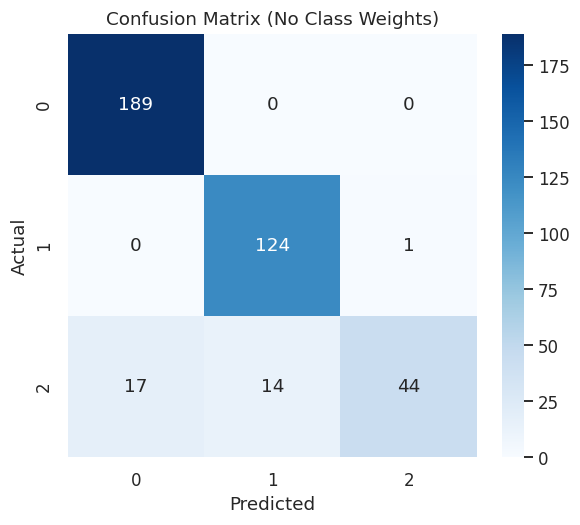

In [52]:
# ── Model without class weights ───────────────────────────────────────────────
log_reg_no_weight = LogisticRegression(random_state=42, multi_class='ovr')
log_reg_no_weight.fit(X_imb_tr_sc, y_imb_tr)
y_pred_no_weight = log_reg_no_weight.predict(X_imb_te_sc)

print("Logistic Regression (No Class Weights):")
print(classification_report(y_imb_te, y_pred_no_weight))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_imb_te, y_pred_no_weight), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (No Class Weights)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Logistic Regression (Class Weight 'balanced'):
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       189
           1       0.95      0.94      0.94       125
           2       0.87      0.81      0.84        75

    accuracy                           0.94       389
   macro avg       0.93      0.91      0.92       389
weighted avg       0.94      0.94      0.94       389



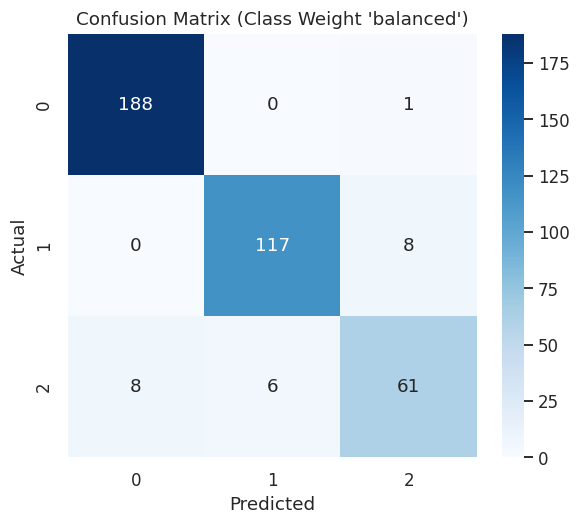

In [53]:
# ── Model with class_weight='balanced' ────────────────────────────────────────
log_reg_balanced = LogisticRegression(random_state=42, multi_class='ovr', class_weight='balanced')
log_reg_balanced.fit(X_imb_tr_sc, y_imb_tr)
y_pred_balanced = log_reg_balanced.predict(X_imb_te_sc)

print("\nLogistic Regression (Class Weight 'balanced'):")
print(classification_report(y_imb_te, y_pred_balanced))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_imb_te, y_pred_balanced), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Class Weight \'balanced\')')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Undersampled class distribution:
performance_category_encoded
0    225
1    225
2    225
Name: count, dtype: int64


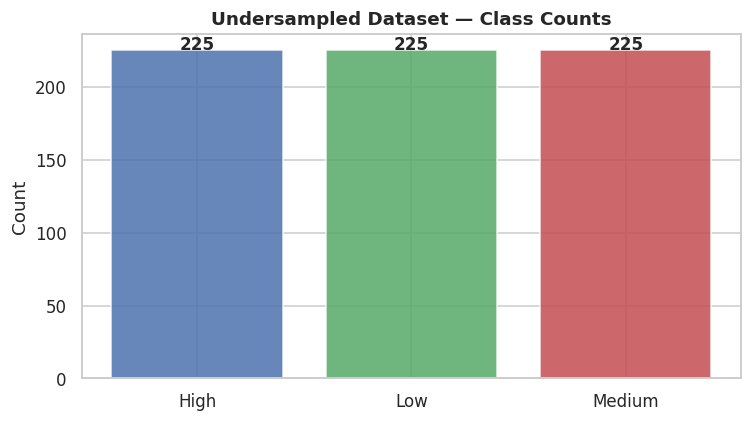

In [60]:
# --- Undersampling ---
rus = RandomUnderSampler(random_state=42)
X_undersampled, y_undersampled = rus.fit_resample(X_imb_tr_sc, y_imb_tr)

print('Undersampled class distribution:')
print(pd.Series(y_undersampled).value_counts().sort_index())

# Visualise undersampled imbalance
class_mapping = {0:'High', 1:'Low', 2:'Medium'}
counts_undersampled = pd.Series(y_undersampled).map(class_mapping).value_counts().sort_index()
fig_us, ax_us = plt.subplots(figsize=(7, 4))
bars_us = ax_us.bar(counts_undersampled.index, counts_undersampled.values, color=PALETTE, edgecolor='white', alpha=0.85)
for bar, val in zip(bars_us, counts_undersampled.values):
    ax_us.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax_us.set_title('Undersampled Dataset — Class Counts', fontweight='bold')
ax_us.set_ylabel('Count')
plt.tight_layout()
plt.show()

### Detailed Metrics for All Models (Multiclass)

In [63]:
all_models = {
    'Logistic Regression': (lr_multi,   X_test_sc),
    'SVM (Linear)':        (svm_linear, X_test_sc), # svm_linear is already trained for binary, needs to be retrained for multiclass
    'SVM (RBF)':           (svm_rbf,    X_test_sc),
}

# Retrain svm_linear for multiclass comparison
svm_linear_multi = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear_multi.fit(X_train_sc, y_train)
all_models['SVM (Linear)'] = (svm_linear_multi, X_test_sc)

metrics_list = []
for name, (model, Xte) in all_models.items():
    yp = model.predict(Xte)
    metrics_list.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1':        f1_score(y_test, yp, average='weighted'),
    })

metrics_df = pd.DataFrame(metrics_list).set_index('Model')
print('Classification Metrics (weighted average for multiclass):')
print(metrics_df.round(4).to_string())

Classification Metrics (weighted average for multiclass):
                     Accuracy  Precision  Recall   F1
Model                                                
Logistic Regression       1.0        1.0     1.0  1.0
SVM (Linear)              1.0        1.0     1.0  1.0
SVM (RBF)                 1.0        1.0     1.0  1.0
